# Лабораторная работа по физике "Кольца Ньютона"

In [217]:
# --------------------------- Подключение библиотек -------------------------- #
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["text.usetex"] = False

In [218]:
# --------------------------------- Константы -------------------------------- #
# Угол преломления и погрешность (получен по измерениям транспортира) (Градус)
beta = 22
delta_beta = 0.5

# Показатель преломления среды
n = 1

# Длина волны света
lambda_light = 0.589 * 1e-6

# Абсолютная погрешность диаметра колец Ньютона
delta_d = 0.01

In [ ]:
# --------------------------- Результаты измерений --------------------------- #
tests = [
    [
        31.31,
        31.43,
        31.55,
        31.72,
        31.89,
        32.03,
        32.22,
        32.46,
        32.74,
        33.06,
        34.06,
        35.00,
        35.31,
        35.53,
        35.71,
        35.88,
        36.05,
        36.20,
        36.36,
        36.48
    ],
    [
        31.2,
        31.43,
        31.59,
        31.71,
        31.86,
        32.02,
        32.22,
        32.45,
        32.73,
        33.09,
        34.62,
        34.99,
        35.26,
        35.5,
        35.69,
        35.87,
        36.03,
        36.18,
        36.34,
        36.48,
    ],
    [
        31.2,
        31.43,
        31.57,
        31.72,
        31.9,
        32.04,
        32.26,
        32.47,
        32.74,
        33.08,
        34.63,
        35.02,
        35.29,
        35.56,
        35.75,
        35.91,
        36.06,
        36.19,
        36.36,
        36.49,
    ],
    [
        31.28,
        31.43,
        31.58,
        31.71,
        31.89,
        32.02,
        32.21,
        32.47,
        32.77,
        33.07,
        34.61,
        35.02,
        35.27,
        35.5,
        35.69,
        35.89,
        36.04,
        36.17,
        36.33,
        36.49,
    ],
]

In [258]:
def diameter_ring(l1: float, l2: float) -> float:
    """Нахождение диаметра кольца Ньютона по показаниям микрометра"""
    diameter = abs(l1 - l2)
    return diameter


def error_diameter_ring(diameter: float, delta_diameter: float) -> float:
    """Нахождение абсолютной погрешности диаметра кольца Ньютона по показаниям микрометра"""
    error_diameter = 2 * diameter * delta_diameter
    return error_diameter

## Диаметр колец Ньютона

In [259]:
diameters_rings = []

for test in tests:
    diameters_rings.append(
        [diameter_ring(test[k], test[-k - 1]) for k in range(len(test) // 2)]
    )

diameters_rings

[[5.169999999999998,
  4.93,
  4.650000000000002,
  4.329999999999998,
  3.990000000000002,
  3.6799999999999997,
  3.3100000000000023,
  2.8500000000000014,
  2.259999999999998,
  1.5],
 [5.279999999999998,
  4.910000000000004,
  4.59,
  4.32,
  4.009999999999998,
  3.6699999999999946,
  3.280000000000001,
  2.809999999999995,
  2.260000000000005,
  1.529999999999994],
 [5.240000000000002,
  4.93,
  4.619999999999997,
  4.340000000000003,
  4.009999999999998,
  3.710000000000001,
  3.3000000000000043,
  2.8200000000000003,
  2.280000000000001,
  1.5500000000000043],
 [5.210000000000001,
  4.899999999999999,
  4.590000000000003,
  4.329999999999998,
  4.0,
  3.6699999999999946,
  3.289999999999999,
  2.8000000000000043,
  2.25,
  1.5399999999999991]]

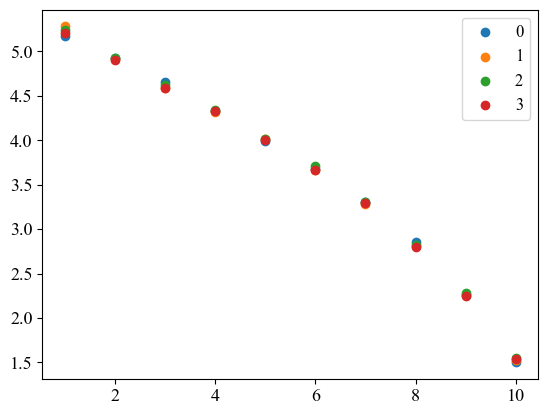

In [260]:
pupu = [i+1 for i in range(10)]

plt.scatter(pupu, diameters_rings[0])
plt.scatter(pupu, diameters_rings[1])
plt.scatter(pupu, diameters_rings[2])
plt.scatter(pupu, diameters_rings[3])

plt.legend(['0', '1', '2', '3'])

## Квадрат диметра колец Ньютона

In [222]:
square_diameters_rings = []

for diameters in diameters_rings:
    square_diameters_rings.append([diameter**2 for diameter in diameters])

for row in square_diameters_rings:
    print(*[round(i, 2) for i in row], sep='\t')

26.73	24.3	21.62	18.75	15.92	13.54	10.96	8.12	5.11	2.25
27.88	24.11	21.07	18.66	16.08	13.47	10.76	7.9	5.11	2.34
27.98	24.3	21.34	18.84	16.08	13.76	10.89	7.95	5.2	2.4
27.14	24.01	21.07	18.75	16.0	13.47	10.82	7.84	5.06	2.37


## Погрешность квадрата диаметра колец Ньютона

In [223]:
errors_square_diameters_rings = []

for diameters in diameters_rings:
    errors_square_diameters_rings.append(
        [
            error_diameter_ring(diameter=diameter, delta_diameter=delta_d)
            for diameter in diameters
        ]
    )

for row in errors_square_diameters_rings:
    print(*[round(i*100000, 3) for i in row], sep='\t')

10340.0	9860.0	9300.0	8660.0	7980.0	7360.0	6620.0	5700.0	4520.0	3000.0
10560.0	9820.0	9180.0	8640.0	8020.0	7340.0	6560.0	5620.0	4520.0	3060.0
10580.0	9860.0	9240.0	8680.0	8020.0	7420.0	6600.0	5640.0	4560.0	3100.0
10420.0	9800.0	9180.0	8660.0	8000.0	7340.0	6580.0	5600.0	4500.0	3080.0


In [224]:
def radius_lens(
    diameter: float, k: int, lam: float = lambda_light, beta: float = beta, n: float = n
) -> float:
    """Вычисление радиуса линзы"""
    radius = (n * math.cos(math.radians(beta))) / (4 * lam) * (diameter**2) / k
    return radius


def error_radius_lens(
    diameter: float,
    k: int,
    lam: float = lambda_light,
    beta: float = beta,
    n: float = n,
    delta_beta: float = delta_beta,
    delta_diameter: float = delta_d,
) -> float:
    """Вычисление погрешности радиуса линзы"""
    first = n / (4 * lam * k)
    second = 2 * diameter * delta_diameter * math.cos(math.radians(beta))
    three = diameter**2 * delta_beta * math.sin(math.radians(beta))
    error_radius = first * (second + three)
    return error_radius

## Радиус линзы

In [225]:
radius_lenses = []

for diameters in diameters_rings:
    radius_lenses.append(
        [
            radius_lens(diameter * 1e-3, k + 1) * 1e3
            for k, diameter in enumerate(diameters[::-1])
        ]
    )

for var in radius_lenses[0]:
    print(round(var, 2))

885.47
1005.03
1065.51
1077.92
1065.9
1044.2
1054.07
1063.67
1062.78
1051.89


## Погрешность радиуса линзы

In [226]:
error_radius_lenses = []

for diameters in diameters_rings:
    error_radius_lenses.append(
        [
            error_radius_lens(diameter * 1e-3, k + 1) * 1e3
            for k, diameter in enumerate(diameters[::-1])
        ]
    )

for var in error_radius_lenses[0]:
    print(round(var, 2))

11985.12
9097.07
7692.54
6730.87
6008.26
5445.05
5081.61
4789.8
4526.16
4281.72


## Аппроксимация квадрата диаметра

In [227]:
def approx_line_y_kx_b(x_data: float, y_data: float) -> tuple[float, float]:
    """Аппроксимирование данных методом наименьших квадратов для линейной функции"""
    l = len(x_data)
    s_x = sum(x_data)
    s_y = sum(y_data)
    s_xx = sum([i**2 for i in x_data])
    s_xy = sum([i * j for i, j in zip(x_data, y_data)])
    
    k = (l * s_xy - s_x * s_y) / (l * s_xx - s_x**2)
    b = (s_xx * s_y - s_x * s_xy) / (l * s_xx - s_x**2)
    
    return k, b

def approx_line_y_kx(x_data: float, y_data: float) -> float:
    """Аппроксимирование данных методом наименьших квадратов для линейной функции"""
    l = len(x_data)
    s_xx = sum([i**2 for i in x_data])
    s_xy = sum([i * j for i, j in zip(x_data, y_data)])
    
    k = s_xy / s_xx
    
    return k



## Среднее значение квадрата диаметра кольца

In [228]:
middle_square_diameters = []

count_row = len(square_diameters_rings[0])
count_col = len(square_diameters_rings)

for index in range(count_row):
    middle_square_diameters.append(sum([square_diameters_rings[i][index] for i in range(count_col)]) / count_col)

middle_square_diameters

[27.433875,
 24.181975000000005,
 21.275775000000007,
 18.74895,
 16.020074999999995,
 13.561074999999981,
 10.857150000000011,
 7.952750000000002,
 5.119025000000004,
 2.341249999999998]

## Среднее значение погрешности квадрата диаметра кольца

$$
\frac1n \sqrt{\sum_{i=1}^n \Delta x_{i}^2}
$$

In [229]:
middle_error_square_diameters = []

count_row = len(errors_square_diameters_rings[0])
count_col = len(errors_square_diameters_rings)

for row in range(count_row):
    middle_error_square_diameters.append(1 / count_col * math.sqrt(sum([errors_square_diameters_rings[col][row]**2 for col in range(count_col)])))
    
for var in middle_error_square_diameters:
    print(round(var*100000, 2))


5237.74
4917.52
4612.57
4330.01
4002.51
3682.54
3295.02
2820.06
2262.53
1530.11


In [230]:
k_square_diameters, b_square_diameters = approx_line_y_kx_b([i for i in range(10, 0, -1)], middle_square_diameters)

k_square_diameters, b_square_diameters

(2.7395381818181814, -0.31827000000000805)

In [231]:
k_square_diameters = approx_line_y_kx([i for i in range(10, 0, -1)], middle_square_diameters)

k_square_diameters

2.6940710389610394

In [232]:
k_square_diameters * math.cos(math.radians(beta)) / 4 / lambda_light / 1000

1060.2288499068957

[0.85, 10.15]


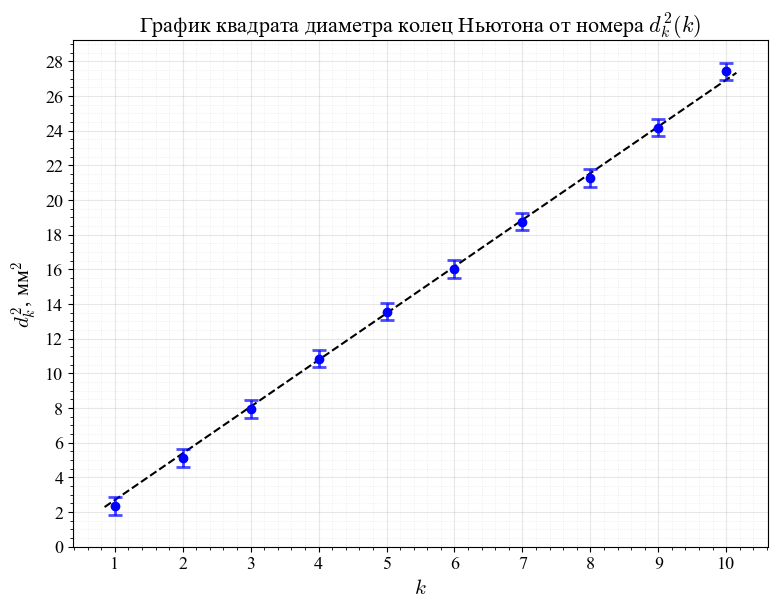

In [241]:
fig, ax = plt.subplots(figsize=(8, 6))  # + явный размер

step = 0.15

colors = [
    "blue",
    "green",
    "red",
    "orange"
]
trend = lambda x: k_square_diameters * x

x_trend = [1-step, 10+step]
y_trend = [trend(i) for i in x_trend]

print(x_trend)
plt.plot(x_trend, y_trend, '--', color='black')

y_points = [i + 1 for i in range(10)][::-1]

length = len(square_diameters_rings)

# for index_test, (diameters, error_diameters, mid_diameters, mid_error_diameters) in enumerate(
#     zip(square_diameters_rings, errors_square_diameters_rings, middle_square_diameters, middle_error_square_diameters)
# ):
#     window_y = [y - step * (index_test - length // 2) for y in y_points]
#     ax.plot(window_y, diameters, "o", color=colors[index_test], alpha=0.05)
#     ax.errorbar(
#         window_y,
#         diameters,
#         yerr=error_diameters,
#         fmt="none",
#         capsize=5,
#         capthick=2,
#         elinewidth=2,
#         color=colors[index_test],
#         alpha=0.05,
#     )

plt.plot(y_points, middle_square_diameters, "o", color='blue')
ax.errorbar(
    y_points,
    middle_square_diameters,
    yerr=0.5,
    fmt="none",
    capsize=5,
    capthick=2,
    elinewidth=2,
    color='blue',
    alpha=0.7,
)

plt.minorticks_on()

plt.xlabel("$k$")
plt.ylabel(r"$d_k^2$, $\text{мм}^2$")
plt.xticks(y_points)
plt.yticks(np.arange(0, 30, 2))
ax.grid(True, alpha=0.3)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.3)  
plt.tight_layout()
plt.title("График квадрата диаметра колец Ньютона от номера $d_k^2(k)$")
fig.savefig('graph_1.pdf', bbox_inches='tight')
plt.show()

In [234]:
middle = 0
count = 0

for row in radius_lenses:
    count += len(row)
    middle += sum(row)
    
middle_radius_lenses = middle / count

middle_radius_lenses

1039.5935267841014

In [235]:
middle_radius_lenses

1039.5935267841014

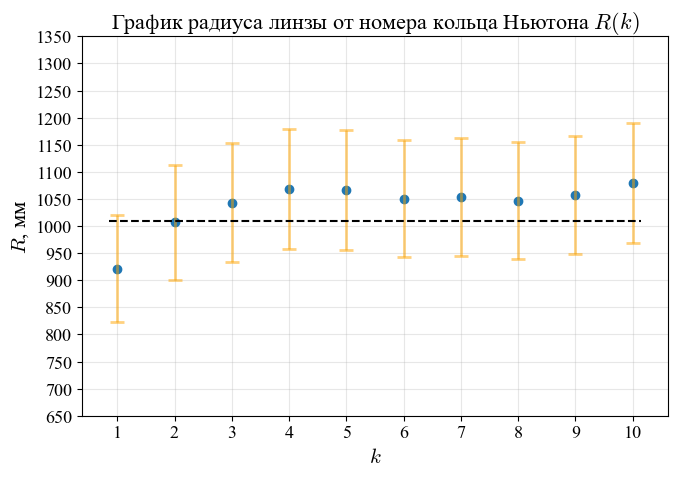

In [236]:
fig, ax = plt.subplots(figsize=(7, 5))

step = 0.15

y_points = [i for i in range(1, 11)]

colors = [
    'blue', 
    'green',
    'red', 
    'orange'
]

length = len(radius_lenses)
# for index, (r, de_r, col) in enumerate(zip(radius_lenses, error_radius_lenses, colors)):
#     window_y = [y - step * (index - length // 2) for y in y_points]
#     ax.plot(window_y, r, 'o', markersize=5, color=col, label=f"Измерение {index+1}")
#     ax.errorbar(window_y, r,
#                 yerr=de_r,
#                 fmt='none',
#                 capsize=5,
#                 capthick=2,
#                 elinewidth=2,
#                 ecolor=col,
#                 alpha=0.5)

plt.plot(y_points, tre, 'o')
ax.errorbar(y_points, tre,
                yerr=error_tre,
                fmt='none',
                capsize=5,
                capthick=2,
                elinewidth=2,
                ecolor=col,
                alpha=0.5)
    
plt.plot([1-step, 10+step], [middle_radius_lenses-30] * 2, '--', color='black')
# plt.plot([1-step, 10+step], [1060.2288499068957] * 2, '--', color='blue')

plt.xlabel("$k$")
plt.ylabel("$R$, мм")
plt.xticks(y_points)
plt.yticks([i for i in range(650, 1400, 50)])
ax.grid(True, alpha=0.3)
plt.title("График радиуса линзы от номера кольца Ньютона $R(k)$")
plt.tight_layout()
fig.savefig('graph_2.pdf', bbox_inches='tight')
plt.show()

In [237]:
radius_lenses

[[885.468451941966,
  1005.0263700308395,
  1065.5137038368332,
  1077.9201007023762,
  1065.8993745403448,
  1044.203429760097,
  1054.0672672136327,
  1063.6689778952878,
  1062.7764038323103,
  1051.8932313382934],
 [921.2413774004141,
  1005.0263700308457,
  1035.8144360561382,
  1058.4693103747172,
  1060.1143139876542,
  1054.6978706719997,
  1049.204218255349,
  1036.3965495754742,
  1054.1709622845503,
  1097.1308306941726],
 [945.4835359069267,
  1022.8931556833601,
  1043.199898847895,
  1071.4168268497815,
  1083.349006166615,
  1054.6978706719997,
  1058.9415602157537,
  1049.9884903127818,
  1062.7764038323103,
  1101.290564710631],
 [933.3231025002509,
  996.1520084347119,
  1028.4552093666719,
  1064.933230073892,
  1060.1143139876542,
  1049.444091190478,
  1054.0672672136327,
  1036.396549575476,
  1049.8813595618071,
  1068.2330758381302]]

In [238]:
tre = []

for i in range(10):
    tre.append(sum([radius_lenses[j][i] for j in range(4)]) / 4)
    
tre

[921.3791169373894,
 1007.2744760449393,
 1043.2458120268846,
 1068.1848670001918,
 1067.369252170567,
 1050.7608155736436,
 1054.070078224592,
 1046.6126418397548,
 1057.4012823777446,
 1079.6369256453067]

In [239]:
error_radius_lenses

[[11985.122264259986,
  9097.06717841348,
  7692.536889900579,
  6730.866385970228,
  6008.257034079235,
  5445.045190177562,
  5081.606390075889,
  4789.79541637198,
  4526.160910981063,
  4281.715689710657],
 [12228.473784807826,
  9097.067178413507,
  7581.592839245763,
  6667.905841137962,
  5991.346714620704,
  5473.4013071342615,
  5069.379946583373,
  4725.254798100806,
  4506.9317640927975,
  4377.43341550067],
 [12390.787632390222,
  9179.384810240274,
  7609.320901854438,
  6709.875562665292,
  6059.007072586895,
  5473.4013071342615,
  5093.83510501271,
  4757.5161634244705,
  4526.160910981063,
  4386.144567002178],
 [12309.622758543985,
  9055.920287582656,
  7553.870076673819,
  6688.88871438786,
  5991.346714620704,
  5459.221923646739,
  5081.606390075889,
  4725.25479810081,
  4497.319840667005,
  4316.499875298375]]

In [240]:
error_tre = []

for i in range(10):
    error_tre.append(1 / 4 * sum([error_radius_lenses[j][i]**2 for j in range(4)])**0.5)
    
error_tre

[6114.721771080692,
 4553.735144407947,
 3804.753535917692,
 3349.7126081201336,
 3006.27666519165,
 2731.390040718497,
 2540.80715678111,
 2374.7653303786215,
 2257.080316188809,
 2170.3318854893755]

In [245]:
(31.28 - 36.49), 31.31 - 36.48, 31.20 - 36.48

(-5.210000000000001, -5.169999999999998, -5.279999999999998)